<a href="https://colab.research.google.com/github/sbaratam-alt/fds-roshini/blob/main/Titanic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TITANIC DATASET

First Five Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare  
0      0         A/5 21171   7.2500  
1      0          PC 17599  71.2833  
2      0  STON/O2. 3101282   7.9250  
3      0            113803  53.1000  
4      0            373450   8.0500  

Last Five Rows
     PassengerId  Survived  Pclass         

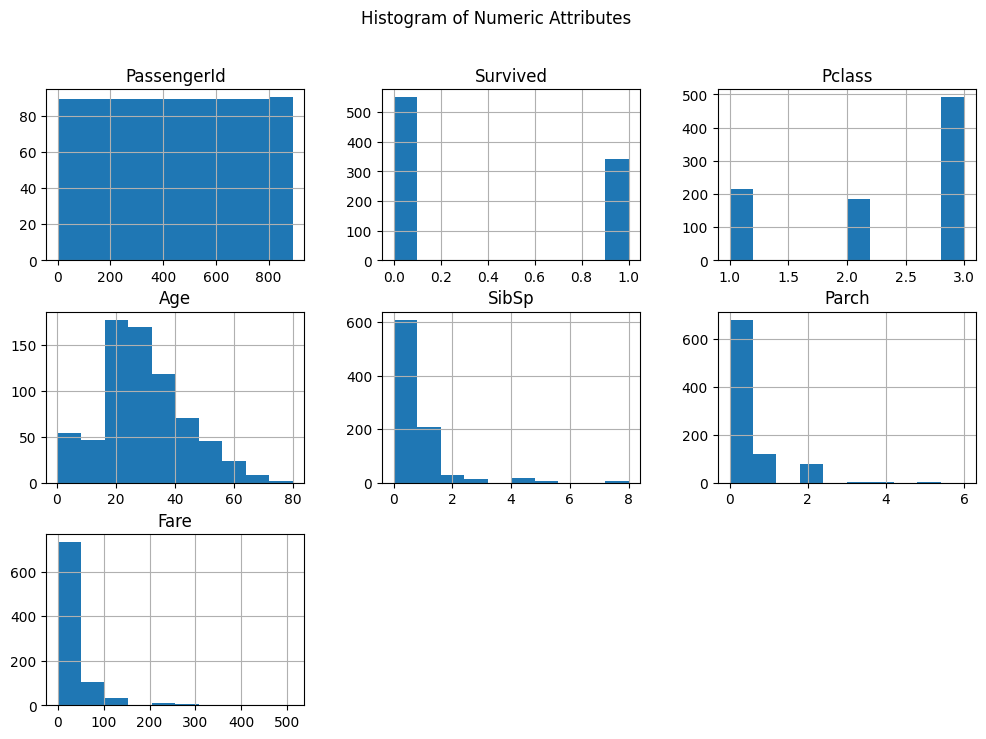

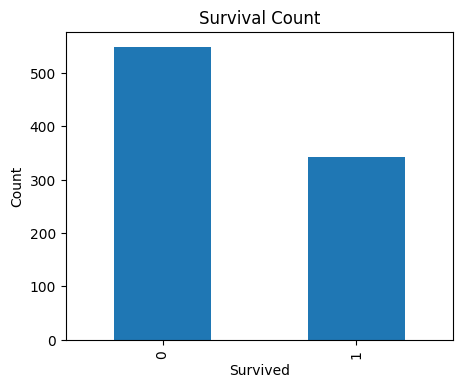

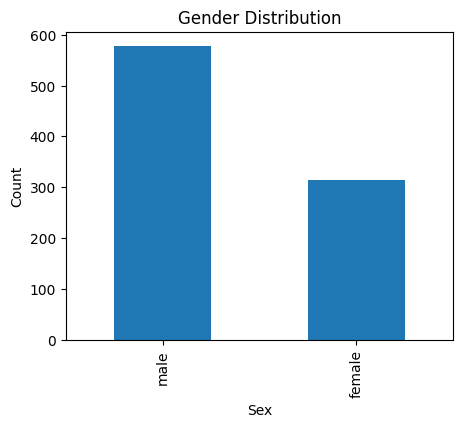

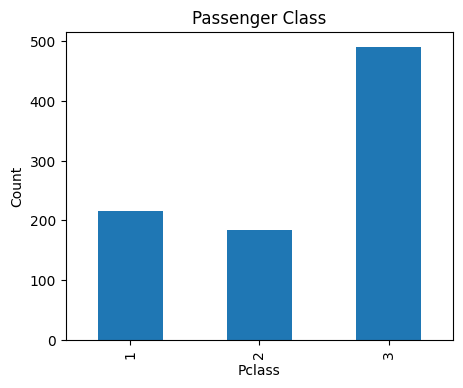

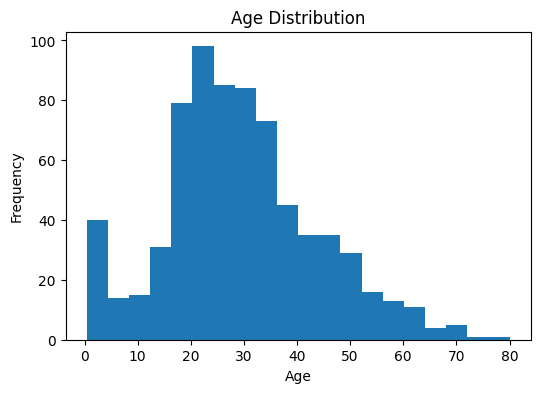

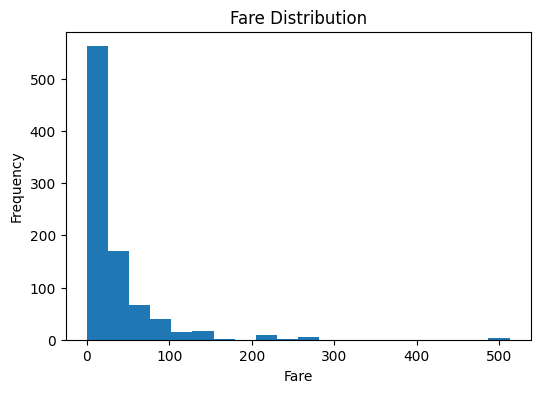



ATTRIBUTE TYPES

Binary Attributes
['Survived']

Numeric Attributes
['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Nominal Attributes
['Name', 'Sex', 'Ticket']


NOMINAL ATTRIBUTE DISSIMILARITY
Sex and Embarked columns are not present.


NUMERIC ATTRIBUTE DISSIMILARITY

Record 1
    Age  Fare
0  22.0  7.25

Record 2
    Age     Fare
1  38.0  71.2833

Euclidean Distance
[[66.00199625]]


In [ ]:
# ==========================================================
# TITANIC DATASET
# a) Read the dataset and perform Exploratory Data Analysis (EDA)
# b) Identify Nominal, Numeric and Binary attributes
# c) Measure dissimilarity for two Nominal attributes
# d) Measure dissimilarity for two Numeric attributes
# ==========================================================

# -------------------------------
# Import Required Libraries
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

# -------------------------------
# Read the Dataset
# -------------------------------

df = pd.read_csv("Titanic-Dataset-selected-columns.csv")

print("="*60)
print("TITANIC DATASET")
print("="*60)

# -------------------------------
# Display First Five Records
# -------------------------------

print("\nFirst Five Rows")
print(df.head())

# -------------------------------
# Display Last Five Records
# -------------------------------

print("\nLast Five Rows")
print(df.tail())

# -------------------------------
# Shape of Dataset
# -------------------------------

print("\nShape of Dataset")
print(df.shape)

# -------------------------------
# Column Names
# -------------------------------

print("\nColumn Names")
print(df.columns)

# -------------------------------
# Dataset Information
# -------------------------------

print("\nDataset Information")
print(df.info())

# -------------------------------
# Data Types
# -------------------------------

print("\nData Types")
print(df.dtypes)

# -------------------------------
# Missing Values
# -------------------------------

print("\nMissing Values")
print(df.isnull().sum())

# -------------------------------
# Number of Duplicate Records
# -------------------------------

print("\nDuplicate Rows")
print(df.duplicated().sum())

# -------------------------------
# Statistical Summary
# -------------------------------

print("\nStatistical Summary")
print(df.describe())

# -------------------------------
# Correlation Matrix
# -------------------------------

print("\nCorrelation Matrix")
print(df.corr(numeric_only=True))

# ==========================================================
# EDA VISUALIZATIONS
# ==========================================================

# -------------------------------
# Histogram
# -------------------------------

df.hist(figsize=(12,8))
plt.suptitle("Histogram of Numeric Attributes")
plt.show()

# -------------------------------
# Survival Count
# -------------------------------

plt.figure(figsize=(5,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

# -------------------------------
# Gender Distribution
# -------------------------------

plt.figure(figsize=(5,4))
df["Sex"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

# -------------------------------
# Passenger Class Distribution
# -------------------------------

if "Pclass" in df.columns:
    plt.figure(figsize=(5,4))
    df["Pclass"].value_counts().sort_index().plot(kind="bar")
    plt.title("Passenger Class")
    plt.xlabel("Pclass")
    plt.ylabel("Count")
    plt.show()

# -------------------------------
# Age Distribution
# -------------------------------

if "Age" in df.columns:
    plt.figure(figsize=(6,4))
    df["Age"].plot(kind="hist", bins=20)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.show()

# -------------------------------
# Fare Distribution
# -------------------------------

if "Fare" in df.columns:
    plt.figure(figsize=(6,4))
    df["Fare"].plot(kind="hist", bins=20)
    plt.title("Fare Distribution")
    plt.xlabel("Fare")
    plt.show()

# ==========================================================
# IDENTIFY ATTRIBUTE TYPES
# ==========================================================

print("\n")
print("="*60)
print("ATTRIBUTE TYPES")
print("="*60)

# Binary Attributes

binary = []

if "Survived" in df.columns:
    binary.append("Survived")

print("\nBinary Attributes")
print(binary)

# Numeric Attributes

numeric = list(df.select_dtypes(include=["int64","float64"]).columns)

# Remove binary columns from numeric list

for col in binary:
    if col in numeric:
        numeric.remove(col)

print("\nNumeric Attributes")
print(numeric)

# Nominal Attributes

nominal = list(df.select_dtypes(include=["object"]).columns)

print("\nNominal Attributes")
print(nominal)

# ==========================================================
# NOMINAL ATTRIBUTE DISSIMILARITY
# ==========================================================

print("\n")
print("="*60)
print("NOMINAL ATTRIBUTE DISSIMILARITY")
print("="*60)

# Selecting two nominal attributes

if "Sex" in df.columns and "Embarked" in df.columns:

    record1 = df.loc[0, ["Sex","Embarked"]]
    record2 = df.loc[1, ["Sex","Embarked"]]

    print("\nRecord 1")
    print(record1)

    print("\nRecord 2")
    print(record2)

    matches = 0

    for value1, value2 in zip(record1, record2):
        if value1 == value2:
            matches += 1

    total = len(record1)

    similarity = matches / total

    dissimilarity = 1 - similarity

    print("\nNumber of Matching Attributes :", matches)
    print("Total Attributes :", total)
    print("Similarity :", similarity)
    print("Nominal Dissimilarity :", dissimilarity)

else:
    print("Sex and Embarked columns are not present.")

# ==========================================================
# NUMERIC ATTRIBUTE DISSIMILARITY
# ==========================================================

print("\n")
print("="*60)
print("NUMERIC ATTRIBUTE DISSIMILARITY")
print("="*60)

# Selecting Age and Fare

if "Age" in df.columns and "Fare" in df.columns:

    point1 = df.loc[[0],["Age","Fare"]].fillna(0)
    point2 = df.loc[[1],["Age","Fare"]].fillna(0)

    print("\nRecord 1")
    print(point1)

    print("\nRecord 2")
    print(point2)

    distance = euclidean_distances(point1, point2)

    print("\nEuclidean Distance")
    print(distance)

else:
    print("Age and Fare columns are not present.")

# ==========================================================
# END OF PROGRAM
# ==========================================================

In [1]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Select numerical columns
numeric_columns = ['age', 'fare', 'sibsp', 'parch']

# -------------------------------
# CENTRAL TENDENCY
# -------------------------------

print("\n========== CENTRAL TENDENCY ==========")

# Mean
print("\nMean:")
print(df[numeric_columns].mean())

# Median
print("\nMedian:")
print(df[numeric_columns].median())

# Mode
print("\nMode:")
print(df[numeric_columns].mode().iloc[0])


# -------------------------------
# DISPERSION
# -------------------------------

print("\n========== DISPERSION ==========")

# Range
print("\nRange:")
print(df[numeric_columns].max() - df[numeric_columns].min())

# Variance
print("\nVariance:")
print(df[numeric_columns].var())

# Standard Deviation
print("\nStandard Deviation:")
print(df[numeric_columns].std())

# Quartiles
print("\nQuartiles:")
print(df[numeric_columns].quantile([0.25, 0.50, 0.75]))

# IQR (Interquartile Range)
print("\nIQR:")
print(
    df[numeric_columns].quantile(0.75)
    - df[numeric_columns].quantile(0.25)
)


# -------------------------------
# COMPLETE DESCRIPTIVE STATISTICS
# -------------------------------

print("\n========== DESCRIPTIVE STATISTICS ==========")

print(df[numeric_columns].describe())

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

========== CENTRAL TENDENCY ==========

Mean:
age      29.699118
fare     32.204208
sibsp     0.523008
parch     0.381594
dtype: float64

Median:
age      28.0000
fare     14.4542
sibsp     0.0000
parch  